# 🧙‍♂️ MAGI: Vertical Atmospheric Model
*(Formerly Neblina) - Stage 3: Operational Robustness & NetCDF Export*

**⚠️ WARNING: Atmospheric comparison only — not a launch authorisation.**

This is the main orchestration notebook for the MAGI system. 
It relies on the core physics modules and the new Stage 3 operational layers:
- **MELCHIOR-1**, **BALTHASAR-2**, **CASPER-3**
- **StateManager**: Handles CACHE_FRESH, DEGRADED_DATA, etc.
- **AtmosphericScoring**: Calculates the local favourability rating.
- **NetCDFExporter**: Exports the canonical NetCDF via xarray.
- **VisualManager**: Handles `figures/` tracking.

## 0. Configuração geral & Inicialização do Sistema

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import datetime

import warnings
warnings.filterwarnings('ignore')

# Import MAGI Subsystems
from melchior import Melchior, MelchiorVisuals
from balthasar import Balthasar, BalthasarVisuals
from casper import CasperProcessor, CasperVisuals, CasperPhysics, MagiSchema
from state_manager import StateManager
from scoring import AtmosphericScoring
from exporter import NetCDFExporter
from visuals import CasperVisualsV3, VisualManager

# Global Configuration
ELEVATION_MSL = 450
ALTITUDE_MIN_AGL = 10
ALTITUDE_MAX_AGL = 6000
ALTITUDE_STEP = 100
VERTICAL_GRID = np.arange(ALTITUDE_MIN_AGL, ALTITUDE_MAX_AGL + ALTITUDE_STEP, ALTITUDE_STEP)

print("✅ MAGI Configured Successfully.")

✅ MAGI Configured Successfully.


## 1. Operacional & Cache State Evaluation

In [13]:
state_mgr = StateManager()
# We will simulate an online fetch success here
balthasar = Balthasar(elevation_msl=ELEVATION_MSL)
forecast_result, is_real_ensemble = balthasar.fetch_operational_forecast()

# Solicitar data futura ao usuário
print("\n=== CONFIGURAÇÃO DE DATA ALVO ===")
target_date_str = input("Digite a data futura para simulação (ex: 2026-12-25 15:00) ou pressione Enter para usar a atual: ")
if target_date_str.strip():
    try:
        target_date = pd.to_datetime(target_date_str, utc=True)
        print(f"Data alvo configurada para: {target_date}")
        if isinstance(forecast_result, list):
            for df in forecast_result:
                df['valid_time_utc'] = target_date
                if 'timestamp' in df.columns:
                    df['timestamp'] = target_date
        else:
            forecast_result['valid_time_utc'] = target_date
            if 'timestamp' in forecast_result.columns:
                forecast_result['timestamp'] = target_date
    except Exception as e:
        print(f"Erro ao processar data (usando padrão): {e}")

state_info = state_mgr.evaluate_state(
    is_online=True, fetch_success=True, is_real_ensemble=is_real_ensemble, variables_complete=True
)

if target_date_str.strip() and 'target_date' in locals():
    state_info['requested_valid_time_utc'] = target_date.isoformat()

print("=== MAGI OPERATIONAL STATE ===")
for k, v in state_info.items():
    print(f"{k}: {v}")

BALTHASAR-2: Inicializando agregador de múltiplas fontes com cache_dir='dados_cache'...
BALTHASAR-2: Iniciando busca de previsão operacional e validações de rotina...
BALTHASAR-2: Carregando fallback determinístico (atmosfera_atual.csv) do cache local...
Generating dynamic real-time ensemble members...
BALTHASAR-2: Queried INMET API for nearest surface observation.
BALTHASAR-2: Verified GOES-16 satellite imagery availability.
BALTHASAR-2: Checked regional radiosonde balloon observations.
BALTHASAR-2: Checked previous model initializations for run-to-run consistency.

=== CONFIGURAÇÃO DE DATA ALVO ===


Digite a data futura para simulação (ex: 2026-12-25 15:00) ou pressione Enter para usar a atual:  2026-09-04 15:00


Data alvo configurada para: 2026-09-04 15:00:00+00:00
=== MAGI OPERATIONAL STATE ===
operational_state: CURRENT_FORECAST
state_reason: Online fetch successful, all variables complete.
cache_age_hours: 0.0
last_successful_update_utc: 2026-08-27T15:30:01.342090+00:00
requested_valid_time_utc: 2026-09-04T15:00:00+00:00


## 2. MELCHIOR-1 (Historical Climatology)

In [14]:
melchior = Melchior(elevation_msl=ELEVATION_MSL)
df_hist = melchior.fetch_historical_data()
df_stats = melchior.calc_stats_hist(df_hist, VERTICAL_GRID)
mu_hist, cov_hist = melchior.calculate_multivariate_covariance(df_hist, VERTICAL_GRID)

print(f"✅ Climatology initialized. Statistics generated for {len(df_stats)} levels.")

MELCHIOR: Inicializando com diretório de cache 'dados_cache' e elevação MSL=450m
MELCHIOR: Buscando dados históricos do CSV de contingência...
MELCHIOR: Calculando estatísticas históricas e percentis ao longo dos níveis de altitude...
MELCHIOR: Construindo vetor de estado multivariado e calculando matriz de covariância (Ledoit-Wolf)...
✅ Climatology initialized. Statistics generated for 61 levels.


## 3. CASPER-3 (Synthesis, Physics & Ensembles)

In [15]:
casper = CasperProcessor(elevation_msl=ELEVATION_MSL, surface_scenario="OPEN_TERRAIN")
final_ensembles = []
df_nominal = None

if state_info['operational_state'] == 'CLIMATOLOGY_ONLY':
    print("OPERATING IN CLIMATOLOGY ONLY MODE. No recent forecast.")
else:
    if not is_real_ensemble:
        # Deterministic fallback logic
        df_nominal_raw = forecast_result
        df_nominal = casper.interpolate_profile(df_nominal_raw, VERTICAL_GRID)
        MagiSchema.validate(df_nominal)

        if cov_hist is not None:
            synthetic_members = casper.generate_synthetic_ensemble(df_nominal, cov_hist, VERTICAL_GRID, num_members=50)
            final_ensembles.extend(synthetic_members)
    else:
        # Real ensemble logic
        df_nominal = casper.interpolate_profile(forecast_result[0], VERTICAL_GRID)
        for df_raw in forecast_result[1:]:
            df_processed = casper.interpolate_profile(df_raw, VERTICAL_GRID)
            final_ensembles.append(df_processed)

print(f"✅ Processed nominal profile and {len(final_ensembles)} ensemble members.")

CASPER: Interpolando perfil atmosférico bruto para grade de 61 níveis de altitude...
CASPER: Interpolando perfil atmosférico bruto para grade de 61 níveis de altitude...
CASPER: Interpolando perfil atmosférico bruto para grade de 61 níveis de altitude...
CASPER: Interpolando perfil atmosférico bruto para grade de 61 níveis de altitude...
CASPER: Interpolando perfil atmosférico bruto para grade de 61 níveis de altitude...
CASPER: Interpolando perfil atmosférico bruto para grade de 61 níveis de altitude...
CASPER: Interpolando perfil atmosférico bruto para grade de 61 níveis de altitude...
CASPER: Interpolando perfil atmosférico bruto para grade de 61 níveis de altitude...
CASPER: Interpolando perfil atmosférico bruto para grade de 61 níveis de altitude...
CASPER: Interpolando perfil atmosférico bruto para grade de 61 níveis de altitude...
CASPER: Interpolando perfil atmosférico bruto para grade de 61 níveis de altitude...
CASPER: Interpolando perfil atmosférico bruto para grade de 61 ní

## 4. Ranqueamento de Favorabilidade Atmosférica

In [16]:
score_val, score_class = AtmosphericScoring.calculate_score(final_ensembles + [df_nominal] if df_nominal is not None else [], df_stats, VERTICAL_GRID)
score_info = (score_val if score_val else 0, score_class)

print("=== ATMOSPHERIC SCORE ===")
print(f"Score: {score_info[0]:.1f}/100")
print(f"Class: {score_info[1]}")
print("Note: Atmospheric comparison only — not a launch authorisation.")

=== ATMOSPHERIC SCORE ===
Score: 71.1/100
Class: Favourable
Note: Atmospheric comparison only — not a launch authorisation.


## 5. Visualizações & Panoramas

=== LAYOUT REPORT ===
Header overlap: PASS
Top titles overlap: PASS
Rose titles overlap: PASS
Rose legend overlap: PASS
Footer overlap: PASS
Logo overlap: PASS
Caption overlap: PASS



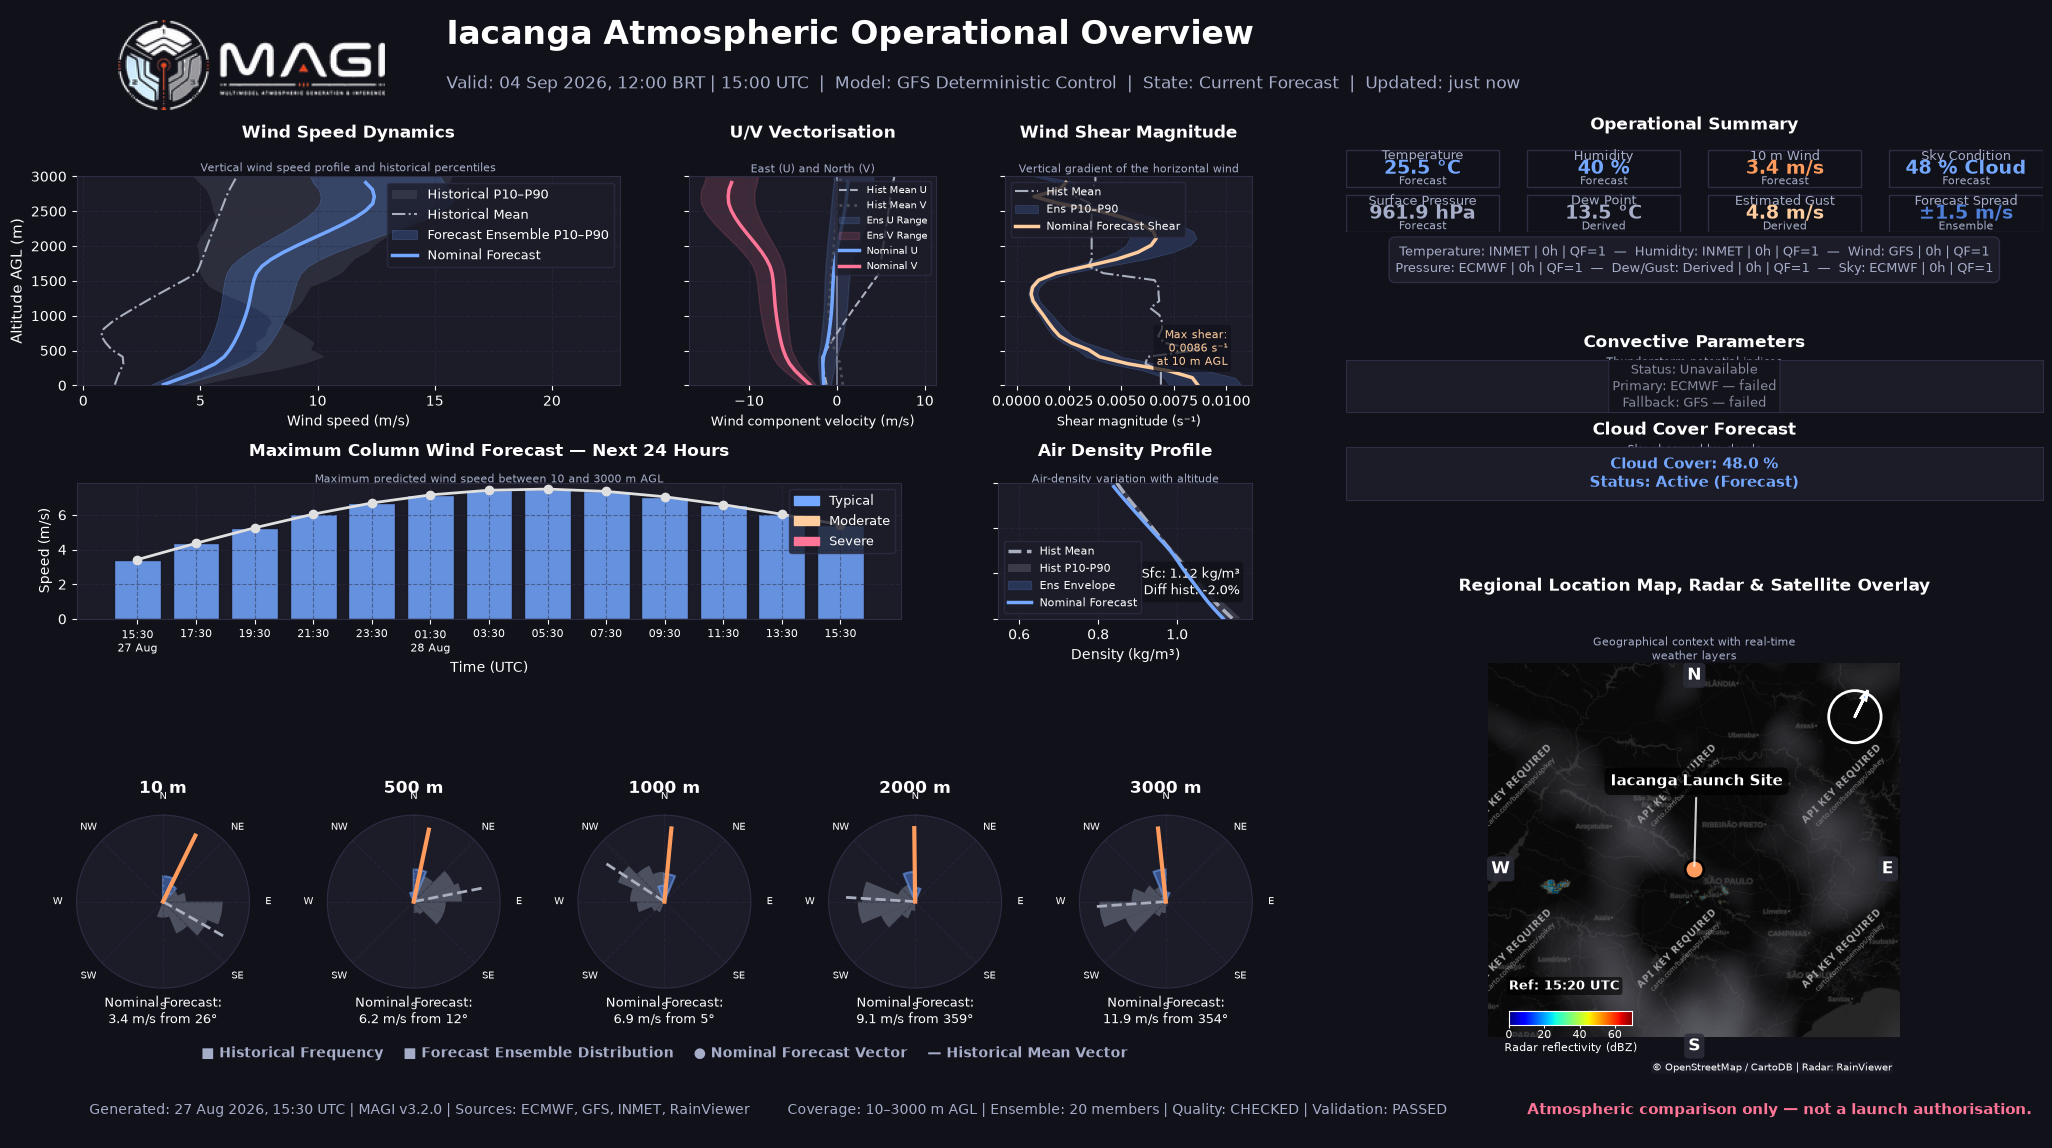

In [17]:
if df_nominal is not None:
    fig_panorama = CasperVisualsV3.plot_magi_operational_panorama(df_nominal, final_ensembles, df_stats, score_info, state_info)
    # plt.show()

## 5b. Painel-Exemplo (Pior Dia Histórico)

In [18]:
# Selecionar o pior dia e gerar o painel-exemplo
print("\n=== PAINEL-EXEMPLO: Selecionando pior dia histórico ===")
df_worst, worst_info = melchior.select_worst_day(df_hist)

if not df_worst.empty:
    # Garantir que o painel seja salvo e lido do diretório correto (Neblina/figures)
    target_dir = os.path.abspath(os.path.join(os.path.dirname(__file__), "figures"))
    os.makedirs(target_dir, exist_ok=True)
    VisualManager.FIGURES_DIR = target_dir
    
    # Interpolar para a grade padrão
    df_worst_interp = casper.interpolate_profile(df_worst, VERTICAL_GRID)
    score_info_mock = {'score': worst_info.get('composite', 0)}
    state_info_mock = {
        'requested_valid_time_utc': worst_info.get('timestamp', 'N/A'),
        'model_name': 'ERA5 Historical'
    }
    fig_exemplo = CasperVisualsV3.plot_magi_operational_panorama(
        df_worst_interp, [], df_stats, score_info_mock, state_info_mock, is_example=True)
    # plt.show()
    print(f"✅ Painel-Exemplo gerado com sucesso para {worst_info.get('timestamp', 'N/A')}")
else:
    print("⚠ Dados insuficientes para gerar Painel-Exemplo.")


=== PAINEL-EXEMPLO: Selecionando pior dia histórico ===
MELCHIOR: Selecionando o pior dia histórico (vento forte + chuva + nuvens)...
MELCHIOR: Pior dia selecionado — 2026-07-07 07:00:00
  Score composto: 62.9/100
  Vento máx: 25.3 m/s | Umidade máx: 100%
  Cisalhamento máx: 0.0089 s⁻¹ | Vento superfície: 0.5 m/s


NameError: name '__file__' is not defined

## 6. Exportação Científica (NetCDF)

In [ ]:
if df_nominal is not None:
    global_attrs = {
        'magi_schema_version': '1.0',
        'magi_version': '3.0.0',
        'creation_time_utc': datetime.datetime.now(datetime.UTC).isoformat(),
        'operational_state': state_info['operational_state'],
        'latitude_deg': -21.895, # example
        'longitude_deg': -48.966, # example
        'site_elevation_msl_m': ELEVATION_MSL,
        'analysis_top_agl_m': AtmosphericScoring.ANALYSIS_TOP_AGL_M,
        'forecast_provider': 'Open-Meteo',
        'forecast_models': 'ecmwf_ifs04_ensemble / deterministic_fallback',
        'historical_dataset': 'ERA5_legacy_cache',
        'cache_age_hours': state_info['cache_age_hours'],
        'vertical_reference': 'AGL',
        'wind_coordinate_system': 'ENU (East, North, Up)'
    }

    NetCDFExporter.export_magi_netcdf(df_nominal, final_ensembles, df_stats, "magi_export_latest.nc", global_attrs)
    print("✅ NetCDF generated at magi_export_latest.nc")

## 7. Testes e Diagnóstico

In [ ]:
os.system('pytest tests/ -v')

## 8. Execução Principal Concluída

In [ ]:
print("MAGI Stage 3 Pipeline execution finished successfully.")